Successfully loaded: Employee.csv

--- Model Performance Comparison ---
Logistic Regression -> Accuracy: 0.8741 | F1 Score: 0.4932
Decision Tree -> Accuracy: 0.7823 | F1 Score: 0.3191
Random Forest -> Accuracy: 0.8435 | F1 Score: 0.2069


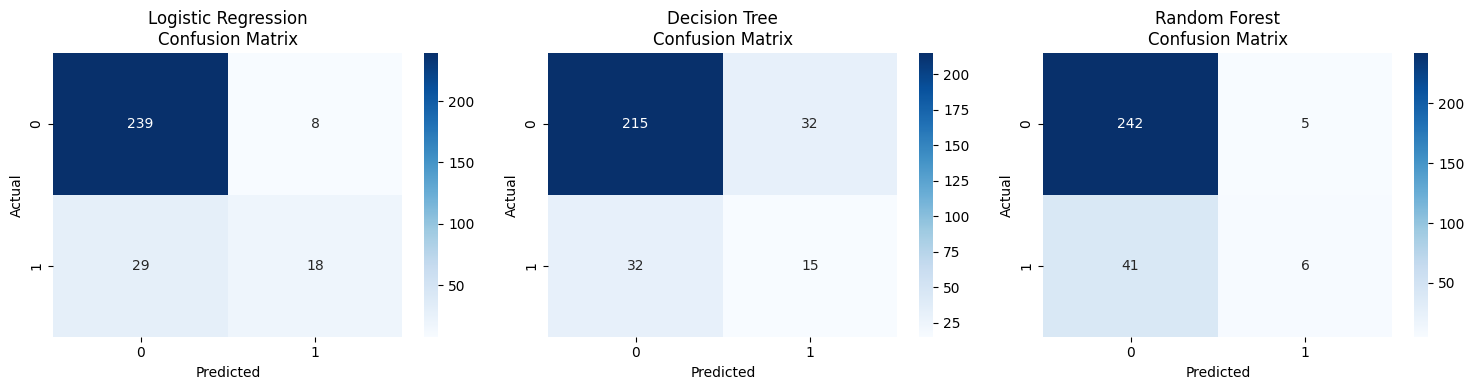

/tmp/ipykernel_1585/580715913.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


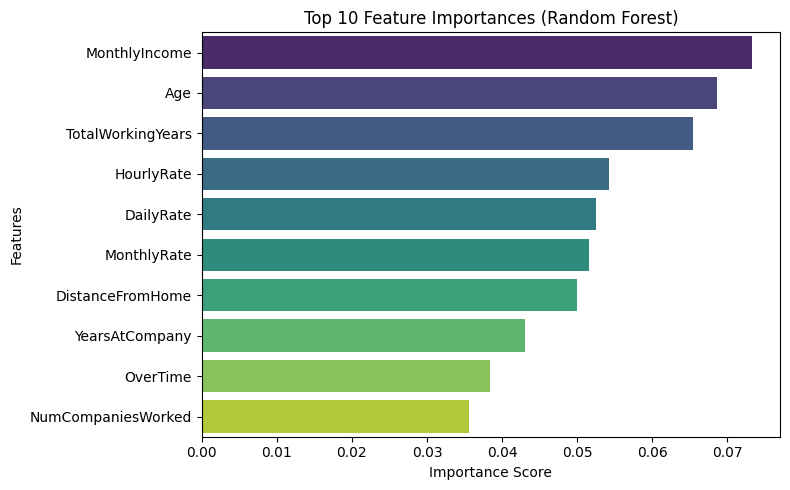

In [3]:
# IBM HR Analytics Employee Attrition & Performance Muhammad Qasim Khan 24F-AI-015
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# IBM HR Analytics Employee Attrition & Performance Muhammad Qasim Khan 24F-AI-015
# 1. Load Dataset
file_path = r'D:\Employee.csv'

if not os.path.exists(file_path):
  file_path = 'Employee.csv'

df = pd.read_csv(file_path)
print(f'Successfully loaded: {file_path}')

# IBM HR Analytics Employee Attrition & Performance Muhammad Qasim Khan 24F-AI-015
# 2. Preprocessing
df = df.drop(
    columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'],
    errors='ignore',
)

label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# IBM HR Analytics Employee Attrition & Performance Muhammad Qasim Khan 24F-AI-015
# 3. Model Training & Comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
  if name == 'Logistic Regression':
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

  results[name] = {
      'Model': model,
      'Predictions': preds,
      'Accuracy': accuracy_score(y_test, preds),
      'F1': f1_score(y_test, preds),
  }

# IBM HR Analytics Employee Attrition & Performance Muhammad Qasim Khan 24F-AI-015
# 4. Evaluation Metrics & Confusion Matrices
print('\n--- Model Performance Comparison ---')
for name, metrics in results.items():
  print(
      f"{name} -> Accuracy: {metrics['Accuracy']:.4f} | F1 Score:"
      f" {metrics['F1']:.4f}"
  )

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, metrics) in zip(axes, results.items()):
  cm = confusion_matrix(y_test, metrics['Predictions'])
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
  ax.set_title(f'{name}\nConfusion Matrix')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# IBM HR Analytics Employee Attrition & Performance Muhammad Qasim Khan 24F-AI-015
# 5. Feature Importance Visualization
rf_model = results['Random Forest']['Model']
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=importances.head(10), y=importances.head(10).index, palette='viridis'
)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()